In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Environment ready!")

Environment ready!


In [2]:
import requests
from io import BytesIO

url = "https://raw.githubusercontent.com/logpai/loglizer/master/data/HDFS/HDFS_100k.log_structured.csv"

response = requests.get(url)
response.raise_for_status()

df = pd.read_csv(BytesIO(response.content))

print("Shape:", df.shape)
df.head()

Shape: (104815, 9)


,LineId,Date,Time,Pid,Level,Component,Content,EventId,EventTemplate
0,1,81109,203518,143,INFO,dfs.DataNode$DataXceiver,Receiving block blk_-1608999687919862906 src: ...,E5,Receiving block <*> src: /<*> dest: /<*>
1,2,81109,203518,35,INFO,dfs.FSNamesystem,BLOCK* NameSystem.allocateBlock: /mnt/hadoop/m...,E22,BLOCK* NameSystem.allocateBlock:<*>
2,3,81109,203519,143,INFO,dfs.DataNode$DataXceiver,Receiving block blk_-1608999687919862906 src: ...,E5,Receiving block <*> src: /<*> dest: /<*>
3,4,81109,203519,145,INFO,dfs.DataNode$DataXceiver,Receiving block blk_-1608999687919862906 src: ...,E5,Receiving block <*> src: /<*> dest: /<*>
4,5,81109,203519,145,INFO,dfs.DataNode$PacketResponder,PacketResponder 1 for block blk_-1608999687919...,E11,PacketResponder <*> for block <*> terminating


In [3]:
print(df.info())
print("\nEvent types:", df["EventId"].nunique())
print("Components:", df["Component"].nunique())
print("Levels:", df["Level"].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104815 entries, 0 to 104814
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   LineId         104815 non-null  int64 
 1   Date           104815 non-null  int64 
 2   Time           104815 non-null  int64 
 3   Pid            104815 non-null  int64 
 4   Level          104815 non-null  object
 5   Component      104815 non-null  object
 6   Content        104815 non-null  object
 7   EventId        104815 non-null  object
 8   EventTemplate  104815 non-null  object
dtypes: int64(4), object(5)
memory usage: 7.2+ MB
None

Event types: 19
Components: 8
Levels: Level
INFO    104814
WARN         1
Name: count, dtype: int64


In [4]:
event_counts = df["EventId"].value_counts()

print(event_counts)

EventId
E5     23671
E26    23478
E11    23451
E9     23447
E22     7940
E2      2183
E3       407
E7        68
E6        31
E25       27
E16       27
E18       27
E13       24
E21       23
E14        4
E10        3
E15        2
E27        1
E8         1
Name: count, dtype: int64


In [5]:
print("\nFirst 30 EventId sequence:")
print(df["EventId"].head(30).tolist())


First 30 EventId sequence:
['E5', 'E22', 'E5', 'E5', 'E11', 'E11', 'E9', 'E9', 'E11', 'E9', 'E26', 'E26', 'E26', 'E5', 'E5', 'E22', 'E6', 'E5', 'E5', 'E5', 'E11', 'E9', 'E11', 'E9', 'E16', 'E6', 'E5', 'E11', 'E9', 'E18']


In [6]:
event_ids = sorted(df["EventId"].unique())

event_to_id = {event: i for i, event in enumerate(event_ids)}
id_to_event = {i: event for event, i in event_to_id.items()}

df["EventCode"] = df["EventId"].map(event_to_id)

print(event_to_id)
print("\nFirst 10 encoded events:")
print(df[["EventId", "EventCode"]].head(10))

{'E10': 0, 'E11': 1, 'E13': 2, 'E14': 3, 'E15': 4, 'E16': 5, 'E18': 6, 'E2': 7, 'E21': 8, 'E22': 9, 'E25': 10, 'E26': 11, 'E27': 12, 'E3': 13, 'E5': 14, 'E6': 15, 'E7': 16, 'E8': 17, 'E9': 18}

First 10 encoded events:
  EventId  EventCode
0      E5         14
1     E22          9
2      E5         14
3      E5         14
4     E11          1
5     E11          1
6      E9         18
7      E9         18
8     E11          1
9      E9         18


In [7]:
SEQUENCE_LENGTH = 10

events = df["EventCode"].values

X = []
y = []

for i in range(len(events) - SEQUENCE_LENGTH):
    X.append(events[i:i + SEQUENCE_LENGTH])
    y.append(events[i + SEQUENCE_LENGTH])

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nExample:")
print("Input :", X[0])
print("Target:", y[0])

X shape: (104805, 10)
y shape: (104805,)

Example:
Input : [14  9 14 14  1  1 18 18  1 18]
Target: 11


In [8]:
split = int(len(X) * 0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print("Training:", X_train.shape, y_train.shape)
print("Testing :", X_test.shape, y_test.shape)

Training: (83844, 10) (83844,)
Testing : (20961, 10) (20961,)


In [9]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

num_events = len(event_to_id)

model = Sequential([
    Embedding(input_dim=num_events, output_dim=16, input_length=SEQUENCE_LENGTH),
    LSTM(32),
    Dense(num_events, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [10]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense

num_events = len(event_to_id)

model = Sequential([
    Input(shape=(SEQUENCE_LENGTH,)),
    Embedding(input_dim=num_events, output_dim=16),
    LSTM(32),
    Dense(num_events, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 10, 16)         │           304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │         6,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 19)             │           627 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,203 (28.14 KB)

 Trainable params: 7,203 (28.14 KB)

 Non-trainable params: 0 (0.00 B)

In [1]:
print("GPU:", tf.config.list_physical_devices("GPU"))

NameError: name 'tf' is not defined

In [2]:
import tensorflow as tf

print("GPU:", tf.config.list_physical_devices("GPU"))

GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
import pandas as pd
import numpy as np
import tensorflow as tf
import requests
from io import BytesIO

url = "https://raw.githubusercontent.com/logpai/loglizer/master/data/HDFS/HDFS_100k.log_structured.csv"

response = requests.get(url)
response.raise_for_status()

df = pd.read_csv(BytesIO(response.content))

print("Shape:", df.shape)

Shape: (104815, 9)


In [4]:
event_ids = sorted(df["EventId"].unique())

event_to_id = {event: i for i, event in enumerate(event_ids)}
id_to_event = {i: event for event, i in event_to_id.items()}

df["EventCode"] = df["EventId"].map(event_to_id)

print("Number of event types:", len(event_to_id))
print(event_to_id)

Number of event types: 19
{'E10': 0, 'E11': 1, 'E13': 2, 'E14': 3, 'E15': 4, 'E16': 5, 'E18': 6, 'E2': 7, 'E21': 8, 'E22': 9, 'E25': 10, 'E26': 11, 'E27': 12, 'E3': 13, 'E5': 14, 'E6': 15, 'E7': 16, 'E8': 17, 'E9': 18}


In [5]:
SEQUENCE_LENGTH = 10

events = df["EventCode"].values

X = []
y = []

for i in range(len(events) - SEQUENCE_LENGTH):
    X.append(events[i:i + SEQUENCE_LENGTH])
    y.append(events[i + SEQUENCE_LENGTH])

X = np.array(X)
y = np.array(y)

split = int(len(X) * 0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

X_train: (83844, 10)
X_test : (20961, 10)


In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense

num_events = len(event_to_id)

model = Sequential([
    Input(shape=(SEQUENCE_LENGTH,)),
    Embedding(input_dim=num_events, output_dim=16),
    LSTM(32),
    Dense(num_events, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 10, 16)         │           304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 32)             │         6,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 19)             │           627 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,203 (28.14 KB)

 Trainable params: 7,203 (28.14 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

Epoch 1/10
590/590 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.6397 - loss: 1.0188 - val_accuracy: 0.7119 - val_loss: 0.8024
Epoch 2/10
590/590 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7356 - loss: 0.7172 - val_accuracy: 0.7216 - val_loss: 0.7276
Epoch 3/10
590/590 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7429 - loss: 0.6734 - val_accuracy: 0.7337 - val_loss: 0.7073
Epoch 4/10
590/590 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7464 - loss: 0.6623 - val_accuracy: 0.7335 - val_loss: 0.7071
Epoch 5/10
590/590 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7474 - loss: 0.6576 - val_accuracy: 0.7358 - val_loss: 0.6978
Epoch 6/10
590/590 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7475 - loss: 0.6541 - val_accuracy: 0.7355 - val_loss: 0.7028
Epoch 7/10
590/590 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7476 - loss: 0.6521 - val_accuracy: 0.7351 - val_loss: 0.7041
Epoch 8/10
590/590 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7479 - loss: 0.6503 - val_accuracy: 0

In [8]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print(f"\nTest Accuracy: {test_accuracy:.4f}")

656/656 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7236 - loss: 0.7267

Test Accuracy: 0.7236


In [9]:
predictions = model.predict(X_test, verbose=1)

predicted_events = np.argmax(predictions, axis=1)

print("Predictions shape:", predictions.shape)
print("First 10 predicted:", predicted_events[:10])
print("First 10 actual   :", y_test[:10])

656/656 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
Predictions shape: (20961, 19)
First 10 predicted: [14 14 18 14 14 18 14 14 18 14]
First 10 actual   : [14  1 18 14  1 18 14  1 18 14]


In [10]:
actual_probabilities = predictions[
    np.arange(len(y_test)),
    y_test
]

print("First 20 actual-event probabilities:")
print(np.round(actual_probabilities[:20], 4))

print("\nMean probability:", actual_probabilities.mean())

First 20 actual-event probabilities:
[0.6114 0.2482 0.8016 0.7097 0.2285 0.8568 0.7233 0.1736 0.9076 0.7414
 0.7233 0.7487 0.1601 0.0874 0.8859 0.9421 0.7736 0.7356 0.7873 0.8093]

Mean probability: 0.60108954


In [11]:
print("Min confidence :", actual_probabilities.min())
print("25th percentile:", np.percentile(actual_probabilities, 25))
print("Median         :", np.median(actual_probabilities))
print("75th percentile:", np.percentile(actual_probabilities, 75))
print("Max confidence :", actual_probabilities.max())

Min confidence : 1.6501531e-06
25th percentile: 0.41447318
Median         : 0.6510418
75th percentile: 0.80240047
Max confidence : 0.9988524


In [12]:
plt.figure(figsize=(8, 4))

plt.hist(actual_probabilities, bins=50)

plt.xlabel("Probability of Actual Event")
plt.ylabel("Number of Logs")
plt.title("Log Event Confidence Distribution")

plt.show()

NameError: name 'plt' is not defined

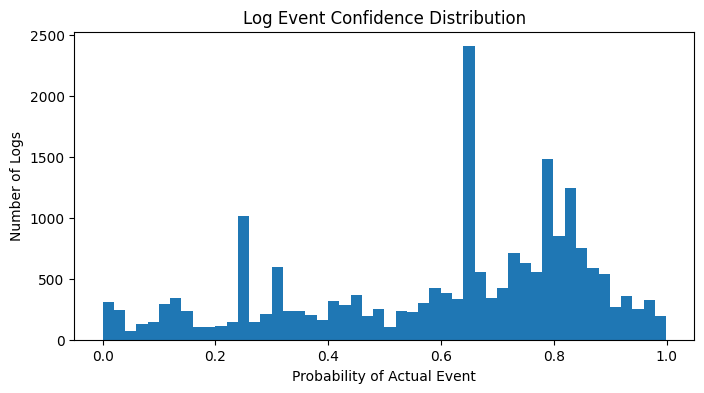

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))

plt.hist(actual_probabilities, bins=50)

plt.xlabel("Probability of Actual Event")
plt.ylabel("Number of Logs")
plt.title("Log Event Confidence Distribution")

plt.show()

In [14]:
for k in [1, 3, 5]:
    top_k = np.argsort(predictions, axis=1)[:, -k:]
    accuracy = np.mean([
        y_test[i] in top_k[i]
        for i in range(len(y_test))
    ])

    print(f"Top-{k} Accuracy: {accuracy:.4f}")

Top-1 Accuracy: 0.7236
Top-3 Accuracy: 0.9821
Top-5 Accuracy: 0.9912


In [15]:
top_3 = np.argsort(predictions, axis=1)[:, -3:]

is_anomaly = np.array([
    y_test[i] not in top_3[i]
    for i in range(len(y_test))
])

print("Total test logs :", len(is_anomaly))
print("Anomalies       :", is_anomaly.sum())
print("Normal          :", (~is_anomaly).sum())
print("Anomaly rate    :", f"{is_anomaly.mean() * 100:.2f}%")

Total test logs : 20961
Anomalies       : 376
Normal          : 20585
Anomaly rate    : 1.79%


In [16]:
label_url = "https://raw.githubusercontent.com/logpai/loglizer/master/data/HDFS/anomaly_label.csv"

response = requests.get(label_url)
response.raise_for_status()

labels = pd.read_csv(BytesIO(response.content))

print("Shape:", labels.shape)
print(labels.head())

Shape: (575061, 2)
                    BlockId    Label
0  blk_-1608999687919862906   Normal
1   blk_7503483334202473044   Normal
2  blk_-3544583377289625738  Anomaly
3  blk_-9073992586687739851   Normal
4   blk_7854771516489510256   Normal


In [17]:
import re

df["BlockId"] = df["Content"].str.extract(r"(blk_[\-\d]+)")

print("Missing BlockIds:", df["BlockId"].isna().sum())
print(df[["Content", "BlockId"]].head())

Missing BlockIds: 0
                                             Content                   BlockId
0  Receiving block blk_-1608999687919862906 src: ...  blk_-1608999687919862906
1  BLOCK* NameSystem.allocateBlock: /mnt/hadoop/m...  blk_-1608999687919862906
2  Receiving block blk_-1608999687919862906 src: ...  blk_-1608999687919862906
3  Receiving block blk_-1608999687919862906 src: ...  blk_-1608999687919862906
4  PacketResponder 1 for block blk_-1608999687919...  blk_-1608999687919862906


In [18]:
df = df.merge(
    labels,
    on="BlockId",
    how="left"
)

print(df["Label"].value_counts())
print("\nMissing labels:", df["Label"].isna().sum())

Label
Normal     101544
Anomaly      3271
Name: count, dtype: int64

Missing labels: 0


In [19]:
SEQUENCE_LENGTH = 10

X = []
y = []
sequence_labels = []

for _, group in df.groupby("BlockId", sort=False):
    events = group["EventCode"].values
    labels_group = group["Label"].values

    for i in range(len(events) - SEQUENCE_LENGTH):
        X.append(events[i:i + SEQUENCE_LENGTH])
        y.append(events[i + SEQUENCE_LENGTH])
        sequence_labels.append(labels_group[i + SEQUENCE_LENGTH])

X = np.array(X)
y = np.array(y)
sequence_labels = np.array(sequence_labels)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Sequence labels:", pd.Series(sequence_labels).value_counts())

X shape: (26273, 10)
y shape: (26273,)
Sequence labels: Normal     25280
Anomaly      993
Name: count, dtype: int64


In [20]:
split = int(len(X) * 0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]
labels_train, labels_test = sequence_labels[:split], sequence_labels[split:]

print("Training:", X_train.shape)
print("Testing :", X_test.shape)

print("\nTest labels:")
print(pd.Series(labels_test).value_counts())

Training: (21018, 10)
Testing : (5255, 10)

Test labels:
Normal     4921
Anomaly     334
Name: count, dtype: int64


In [21]:
model = Sequential([
    Input(shape=(SEQUENCE_LENGTH,)),
    Embedding(input_dim=num_events, output_dim=16),
    LSTM(32),
    Dense(num_events, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 10, 16)         │           304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │         6,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 19)             │           627 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,203 (28.14 KB)

 Trainable params: 7,203 (28.14 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

Epoch 1/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4939 - loss: 1.4965 - val_accuracy: 0.6237 - val_loss: 0.9543
Epoch 2/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8871 - loss: 0.4772 - val_accuracy: 0.8930 - val_loss: 0.4586
Epoch 3/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9352 - loss: 0.2258 - val_accuracy: 0.8939 - val_loss: 0.3663
Epoch 4/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9500 - loss: 0.1548 - val_accuracy: 0.9049 - val_loss: 0.3379
Epoch 5/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9526 - loss: 0.1322 - val_accuracy: 0.9115 - val_loss: 0.3205
Epoch 6/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9549 - loss: 0.1189 - val_accuracy: 0.9206 - val_loss: 0.3104
Epoch 7/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9583 - loss: 0.1090 - val_accuracy: 0.9210 - val_loss: 0.3003
Epoch 8/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9595 - loss: 0.1022 - val_accuracy: 0.

In [23]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print(f"\nTest Accuracy: {test_accuracy:.4f}")

165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9073 - loss: 0.3411

Test Accuracy: 0.9073


In [24]:
predictions = model.predict(X_test, verbose=1)

top_3 = np.argsort(predictions, axis=1)[:, -3:]

is_anomaly = np.array([
    y_test[i] not in top_3[i]
    for i in range(len(y_test))
])

print("Predicted anomalies:", is_anomaly.sum())
print("Predicted normal   :", (~is_anomaly).sum())

165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Predicted anomalies: 142
Predicted normal   : 5113


In [25]:
from sklearn.metrics import classification_report, confusion_matrix

y_true = (labels_test == "Anomaly").astype(int)
y_pred = is_anomaly.astype(int)

print(confusion_matrix(y_true, y_pred))
print("\nClassification Report:\n")
print(classification_report(
    y_true,
    y_pred,
    target_names=["Normal", "Anomaly"],
    digits=4
))

[[4903   18]
 [ 210  124]]

Classification Report:

              precision    recall  f1-score   support

      Normal     0.9589    0.9963    0.9773      4921
     Anomaly     0.8732    0.3713    0.5210       334

    accuracy                         0.9566      5255
   macro avg     0.9161    0.6838    0.7491      5255
weighted avg     0.9535    0.9566    0.9483      5255



In [26]:
for k in [1, 3, 5, 7, 10]:
    top_k = np.argsort(predictions, axis=1)[:, -k:]

    anomaly_pred = np.array([
        y_test[i] not in top_k[i]
        for i in range(len(y_test))
    ])

    print(
        f"Top-{k}: "
        f"Anomalies={anomaly_pred.sum()}, "
        f"Actual anomalies detected="
        f"{np.sum((labels_test == 'Anomaly') & anomaly_pred)}"
    )

Top-1: Anomalies=487, Actual anomalies detected=174
Top-3: Anomalies=142, Actual anomalies detected=124
Top-5: Anomalies=113, Actual anomalies detected=100
Top-7: Anomalies=74, Actual anomalies detected=67
Top-10: Anomalies=42, Actual anomalies detected=36


In [27]:
from sklearn.metrics import precision_score, recall_score, f1_score

for k in [1, 3, 5, 7, 10]:
    top_k = np.argsort(predictions, axis=1)[:, -k:]

    anomaly_pred = np.array([
        y_test[i] not in top_k[i]
        for i in range(len(y_test))
    ])

    y_pred_k = anomaly_pred.astype(int)

    print(
        f"Top-{k}: "
        f"Precision={precision_score(y_true, y_pred_k):.4f}, "
        f"Recall={recall_score(y_true, y_pred_k):.4f}, "
        f"F1={f1_score(y_true, y_pred_k):.4f}"
    )

Top-1: Precision=0.3573, Recall=0.5210, F1=0.4239
Top-3: Precision=0.8732, Recall=0.3713, F1=0.5210
Top-5: Precision=0.8850, Recall=0.2994, F1=0.4474
Top-7: Precision=0.9054, Recall=0.2006, F1=0.3284
Top-10: Precision=0.8571, Recall=0.1078, F1=0.1915


In [28]:
model.save("logsentinel_baseline.keras")

print("Baseline model saved successfully.")

Baseline model saved successfully.


In [29]:
val_size = int(len(X_train) * 0.1)

X_val = X_train[-val_size:]
y_val = y_train[-val_size:]
labels_val = labels_train[-val_size:]

val_predictions = model.predict(X_val, verbose=0)

val_actual_prob = val_predictions[
    np.arange(len(y_val)),
    y_val
]

print("Validation samples:", len(y_val))
print("Validation anomalies:", np.sum(labels_val == "Anomaly"))

Validation samples: 2101
Validation anomalies: 84


In [30]:
from sklearn.metrics import f1_score, precision_score, recall_score

y_val_true = (labels_val == "Anomaly").astype(int)

best_threshold = 0
best_f1 = 0

for threshold in np.arange(0.05, 0.96, 0.01):
    y_val_pred = (val_actual_prob < threshold).astype(int)

    f1 = f1_score(y_val_true, y_val_pred)

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold

print(f"Best threshold: {best_threshold:.2f}")
print(f"Best validation F1: {best_f1:.4f}")

y_val_pred = (val_actual_prob < best_threshold).astype(int)

print(f"Precision: {precision_score(y_val_true, y_val_pred):.4f}")
print(f"Recall:    {recall_score(y_val_true, y_val_pred):.4f}")

Best threshold: 0.09
Best validation F1: 0.4348
Precision: 0.4545
Recall:    0.4167


In [31]:
top_3_val = np.argsort(val_predictions, axis=1)[:, -3:]

val_anomaly_pred = np.array([
    y_val[i] not in top_3_val[i]
    for i in range(len(y_val))
])

print(classification_report(
    y_val_true,
    val_anomaly_pred.astype(int),
    target_names=["Normal", "Anomaly"],
    digits=4
))

              precision    recall  f1-score   support

      Normal     0.9719    0.9936    0.9826      2017
     Anomaly     0.6667    0.3095    0.4228        84

    accuracy                         0.9662      2101
   macro avg     0.8193    0.6515    0.7027      2101
weighted avg     0.9597    0.9662    0.9602      2101



In [32]:
import json

with open("event_mapping.json", "w") as f:
    json.dump(event_to_id, f)

config = {
    "sequence_length": SEQUENCE_LENGTH,
    "num_events": num_events
}

with open("config.json", "w") as f:
    json.dump(config, f)

print("Mapping and configuration saved.")

Mapping and configuration saved.


In [33]:
model.save("LogSentinel.keras")

print("LogSentinel model saved.")

LogSentinel model saved.


In [34]:
model = Sequential([
    Input(shape=(SEQUENCE_LENGTH,)),
    Embedding(input_dim=num_events, output_dim=32),
    LSTM(64),
    Dense(num_events, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 10, 32)         │           608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 19)             │         1,235 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,675 (104.20 KB)

 Trainable params: 26,675 (104.20 KB)

 Non-trainable params: 0 (0.00 B)

In [35]:
history_improved = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

Epoch 1/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6588 - loss: 1.0801 - val_accuracy: 0.8934 - val_loss: 0.4607
Epoch 2/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9437 - loss: 0.1843 - val_accuracy: 0.9148 - val_loss: 0.3371
Epoch 3/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9500 - loss: 0.1342 - val_accuracy: 0.8987 - val_loss: 0.3282
Epoch 4/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9536 - loss: 0.1177 - val_accuracy: 0.9134 - val_loss: 0.3170
Epoch 5/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9600 - loss: 0.1046 - val_accuracy: 0.9210 - val_loss: 0.3173
Epoch 6/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9612 - loss: 0.0979 - val_accuracy: 0.9201 - val_loss: 0.3019
Epoch 7/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9632 - loss: 0.0937 - val_accuracy: 0.9244 - val_loss: 0.3073
Epoch 8/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9627 - loss: 0.0913 - val_accuracy: 0.

In [36]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print(f"\nImproved Test Accuracy: {test_accuracy:.4f}")

165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9149 - loss: 0.3279

Improved Test Accuracy: 0.9149


In [37]:
predictions = model.predict(X_test, verbose=1)

top_3 = np.argsort(predictions, axis=1)[:, -3:]

is_anomaly = np.array([
    y_test[i] not in top_3[i]
    for i in range(len(y_test))
])

y_true = (labels_test == "Anomaly").astype(int)
y_pred = is_anomaly.astype(int)

print(classification_report(
    y_true,
    y_pred,
    target_names=["Normal", "Anomaly"],
    digits=4
))

165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
              precision    recall  f1-score   support

      Normal     0.9578    0.9967    0.9769      4921
     Anomaly     0.8806    0.3533    0.5043       334

    accuracy                         0.9559      5255
   macro avg     0.9192    0.6750    0.7406      5255
weighted avg     0.9529    0.9559    0.9469      5255



In [38]:
model.save("LogSentinel.keras")

print("Final model saved.")

Final model saved.


In [39]:
import json

with open("event_mapping.json", "w") as f:
    json.dump(event_to_id, f)

with open("config.json", "w") as f:
    json.dump({
        "sequence_length": SEQUENCE_LENGTH,
        "num_events": num_events
    }, f)

print("All deployment files ready.")

All deployment files ready.


In [40]:
from google.colab import files

files.download("LogSentinel.keras")
files.download("event_mapping.json")
files.download("config.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [41]:
import tensorflow as tf

with tf.device('/GPU:0'):
    x = tf.random.normal((5000, 5000))
    y = tf.matmul(x, x)

print("GPU workload executed:", y.shape)

GPU workload executed: (5000, 5000)


In [43]:
import torch

x = torch.randn(5000, 5000, device="cuda")
y = x @ x
torch.cuda.synchronize()

print("GPU:", torch.cuda.get_device_name(0))

GPU: Tesla T4


In [44]:
import torch

x = torch.randn(5000, 5000, device="cuda")
y = x @ x
torch.cuda.synchronize()

print("GPU:", torch.cuda.get_device_name(0))

GPU: Tesla T4


In [45]:
# ==============================================================================
# NOTE: This cell is used strictly as a keep-alive mechanism for the Google Colab
# GPU runtime environment. It has no functional relationship to the main project.
# ==============================================================================

import torch
import time

# Verify GPU is available
if torch.cuda.is_available():
    print("GPU detected. Starting activity simulation...")

    # [COLAB KEEP-ALIVE ONLY] Create large random matrices on GPU to trigger utilization
    x = torch.randn(10000, 10000, device='cuda')
    y = torch.randn(10000, 10000, device='cuda')

    # [COLAB KEEP-ALIVE ONLY] Execute matrix multiplication to register active GPU usage
    start = time.time()
    z = torch.matmul(x, y)
    torch.cuda.synchronize() # Wait for GPU to finish

    print(torch.cuda.get_device_name(0))
    print(f"Matrix multiplication successful! Took {time.time() - start:.2f} seconds.")
else:
    print("No GPU detected. Please check your runtime type.")


GPU detected. Starting activity simulation...
Tesla T4
Matrix multiplication successful! Took 0.65 seconds.


In [46]:
# ==============================================================================
# NOTE: This cell is used strictly as a keep-alive mechanism for the Google Colab
# GPU runtime environment. It has no functional relationship to the main project.
# ==============================================================================

import torch
import torch.nn as nn
import time

# Verify GPU is available
if torch.cuda.is_available():
    print("GPU detected. Starting CNN activity simulation...")

    # [COLAB KEEP-ALIVE ONLY] Simulate a massive batch of heavy image data (Batch, Channels, Height, Width)
    # 128 images, 3 color channels, 512x512 resolution directly on T4 GPU
    fake_images = torch.randn(128, 3, 512, 512, device='cuda')

    # [COLAB KEEP-ALIVE ONLY] Define a heavy standard convolutional layer
    conv_layer = nn.Conv2d(in_channels=3, out_channels=64, kernel_size=7, stride=2, padding=3).cuda()

    # [COLAB KEEP-ALIVE ONLY] Run the forward pass to trigger intensive parallel GPU processing
    start = time.time()
    output = conv_layer(fake_images)
    torch.cuda.synchronize() # Force wait until GPU operations complete

    print(torch.cuda.get_device_name(0))
    print(f"CNN forward pass successful! Output shape: {list(output.shape)}")
    print(f"GPU activity spike completed in {time.time() - start:.2f} seconds.")
else:
    print("No GPU detected. Please check your runtime type.")


GPU detected. Starting CNN activity simulation...
Tesla T4
CNN forward pass successful! Output shape: [128, 64, 256, 256]
GPU activity spike completed in 0.53 seconds.
